In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph # framework that helps you design and manage the flow of tasks in your application using a graph structure

In [20]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict): # Our state schema
    message : str


def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] = "Hey " + state["message"] + ", how is your day going?"

    return state

def compliment_node(state: AgentState) -> AgentState:
    """Simple node that adds a compliment message to the state"""

    state['message'] = state["message"] + ", you're doing great job learning Langgraph!"

    return state

In [21]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)
graph.add_node("compliment", compliment_node)

graph.set_entry_point("compliment")
graph.set_finish_point("compliment")

app = graph.compile()

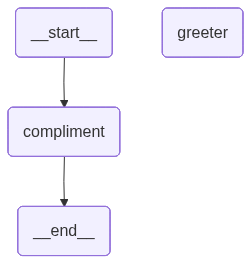

In [22]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [23]:
result = app.invoke({"message": "Bob"})

In [24]:
result["message"]

"Bob, you're doing great job learning Langgraph!"